# Sampling v2 — Stratified by `code_name`

**Goal**: Sample ~20% of total utterances from the Gemini annotations in `outputs/`, with a more uniform distribution across the high-level `code_name` categories.

**Strategy**:
- Load all utterances from every conference in `outputs/` (schema: `utterance_annotations` → `codes` list → `code_name` + `subcode`)
- Use only the **high-level `code_name`** — filter out snake_case entries that are subcodes leaking in
- For multi-label utterances, assign the **rarest** code as the primary (pulls scarce categories forward)
- Iterative quota sampling: sort categories by availability ascending, divide remaining budget evenly each round → nearly flat distribution
- Output: Excel with `conf`, `session`, `file_path`, `timestamp`, `speaker`, `transcript`, `primary_code`, `code_names`, behavioural features, plus blank annotation columns for human raters

In [1]:
import os
import json
import glob
import math
import random
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Always run from the repo root regardless of where Jupyter launched from
# (this notebook lives at analysis_v2/notebooks/)
_HERE = os.path.abspath('')
if os.path.basename(_HERE) == 'notebooks':
    os.chdir(os.path.join(_HERE, '..', '..'))
elif os.path.basename(_HERE) == 'analysis_v2':
    os.chdir(os.path.join(_HERE, '..'))
print('Working directory:', os.getcwd())

RANDOM_SEED     = 42
random.seed(RANDOM_SEED)

BASE_DIR        = 'outputs'     # top-level outputs/ folder
TARGET_FRACTION = 0.20
OUTPUT_EXCEL    = 'analysis_v2/notebooks/sampled_v2.xlsx'
DIST_PNG        = 'analysis_v2/notebooks/sampled_v2_distribution.png'

def is_high_level_code(name: str) -> bool:
    """
    Return True for Title-Case / spaced code_names (the real high-level categories).
    Filters out snake_case subcodes that leak into the code_name field in some files.
    """
    name = name.strip()
    if not name or name.lower() == 'none':
        return False
    # snake_case → subcode; Title Case with spaces → high-level
    return '_' not in name

Working directory: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis


## 1 · Load all utterances

In [2]:
rows = []

all_json_files = sorted(glob.glob(os.path.join(BASE_DIR, '**', '*.json'), recursive=True))
print(f'Total JSON files found: {len(all_json_files)}')

skipped = 0
for fp in all_json_files:
    # Path structure: outputs/{conf}/{session}/{filename.json}
    rel   = os.path.relpath(fp, BASE_DIR)      # e.g. 2021ABI/output_2021_05_21_ABI_S1/Bot_4_..._chunk3.json
    parts = rel.split(os.sep)
    conf    = parts[0] if len(parts) > 0 else ''
    session = parts[1] if len(parts) > 1 else ''
    fname   = parts[2] if len(parts) > 2 else os.path.basename(fp)

    try:
        with open(fp) as f:
            data = json.load(f)
    except Exception:
        skipped += 1
        continue

    utterances = data.get('utterance_annotations', [])

    for utt in utterances:
        # Extract only high-level code_names (filter out snake_case subcodes)
        code_names = []
        for code in utt.get('codes', []):
            cn = code.get('code_name', '').strip()
            if is_high_level_code(cn):
                code_names.append(cn)

        rows.append({
            'conf'              : conf,
            'session'           : session,
            'folder'            : f"{conf}/{session}",
            'file'              : fname,
            'file_path'         : os.path.join(BASE_DIR, conf, session, fname),
            'timestamp'         : utt.get('timestamp', ''),
            'speaker'           : utt.get('speaker', ''),
            'transcript'        : utt.get('transcript', utt.get('utterance_text', '')),
            'speaking_duration' : utt.get('speaking_duration_seconds', ''),
            'nod_count'         : utt.get('nod_count', ''),
            'shared_affect'     : utt.get('shared_affect', ''),
            'any_smile_other'   : utt.get('any_smile_other', ''),
            'distracted_count'  : utt.get('distracted_participant_count', ''),
            'interruption_type' : utt.get('interruption_type', ''),
            'overlap'           : utt.get('audible_backchannel', ''),
            'vocal_enthusiasm'  : utt.get('vocal_enthusiasm', ''),
            'code_names'        : code_names,
            'n_codes'           : len(code_names),
        })

print(f'Skipped (empty/invalid): {skipped}')
df_all = pd.DataFrame(rows)
print(f'\nTotal utterances loaded : {len(df_all):,}')
print(f'Utterances with ≥1 code : {(df_all["n_codes"] > 0).sum():,}')
print(f'Utterances with no code : {(df_all["n_codes"] == 0).sum():,}')
print(f'\nConferences:')
print(df_all['conf'].value_counts().to_string())

Total JSON files found: 1325


Skipped (empty/invalid): 39

Total utterances loaded : 25,874
Utterances with ≥1 code : 22,833
Utterances with no code : 3,041

Conferences:
conf
2021CMC    4121
2021ABI    3492
2021SLU    3422
2021NES    3215
2021MZT    3189
2021MND    3128
2022MND    2704
2020NES    2603


## 2 · Raw code-name distribution

In [3]:
code_freq = Counter()
for codes in df_all['code_names']:
    code_freq.update(codes)

print("Code-name counts (annotation-level, before sampling):")
for code, cnt in code_freq.most_common():
    print(f"  {cnt:5d}  {code}")
print(f"\nTotal annotation instances: {sum(code_freq.values()):,}")

Code-name counts (annotation-level, before sampling):
  14403  Pronoun Framing
   6938  Knowledge Sharing
   4452  Idea Management
   4053  Evaluation Practices
   3484  Coordination and Decision Practices
   3237  Information Seeking
   2371  Participation Dynamics
   2029  Relational Climate
   1985  Integration Practices
    406  Epistemic Bridging
    231  Broader Significance
    177  Complementarity Articulation
    139  Idea Ownership and Attribution
    131  Role Anticipation
    106  Future-Oriented Language
     14  Idea Novelty Signal
      8  ambiguous
      5  Extends Existing Idea
      2  Personal Disclosure
      2  Idea Ownership
      1  Prior Relationship Signal
      1  gatekeeps

Total annotation instances: 44,175


## 3 · Assign primary code

For utterances with **multiple** codes, the rarest code (globally) is chosen as the primary.
This naturally pulls scarce categories (e.g. *Decision & Confirmation*) to the front of the
stratification queue so they are never under-sampled.

In [4]:
def assign_primary(code_list, freq):
    """Return the rarest code in code_list, or None if the list is empty."""
    if not code_list:
        return None
    return min(code_list, key=lambda c: freq.get(c, 0))

# Work only with utterances that have at least one code
df_coded = df_all[df_all['n_codes'] > 0].copy()
df_coded['primary_code'] = df_coded['code_names'].apply(
    lambda codes: assign_primary(codes, code_freq)
)

print("Primary-code distribution (utterance-level):")
vc = df_coded['primary_code'].value_counts()
for code, cnt in vc.items():
    print(f"  {cnt:5d}  {code}")
print(f"\nTotal coded utterances: {len(df_coded):,}")

Primary-code distribution (utterance-level):
   3869  Knowledge Sharing
   3398  Evaluation Practices
   2919  Information Seeking
   2767  Idea Management
   2563  Coordination and Decision Practices
   2103  Participation Dynamics
   1891  Relational Climate
   1798  Integration Practices
    398  Epistemic Bridging
    318  Pronoun Framing
    227  Broader Significance
    173  Complementarity Articulation
    139  Idea Ownership and Attribution
    131  Role Anticipation
    106  Future-Oriented Language
     14  Idea Novelty Signal
      8  ambiguous
      5  Extends Existing Idea
      2  Personal Disclosure
      2  Idea Ownership
      1  Prior Relationship Signal
      1  gatekeeps

Total coded utterances: 22,833


## 4 · Stratified sampling

Target = 20 % of **all** utterances (coded + uncoded).
Budget is split evenly across the `N` code categories; categories with fewer utterances
than their share are taken in full and the remaining budget rolls over proportionally.

In [5]:
total_utterances = len(df_all)
target_n         = math.floor(total_utterances * TARGET_FRACTION)

# Sort categories by ascending availability so constrained ones are handled first.
# Iterative quota: each round the remaining budget is divided equally among
# the remaining categories, so leftover from small categories is spread evenly.
avail = {cat: len(df_coded[df_coded['primary_code'] == cat])
         for cat in df_coded['primary_code'].unique()}
cats_asc = sorted(avail, key=lambda c: avail[c])   # ascending by availability
n_cats   = len(cats_asc)

print(f"Total utterances      : {total_utterances:,}")
print(f"20 % target           : {target_n:,}")
print(f"Code categories       : {n_cats}")
print()

per_cat_plan   = {}
remaining      = target_n

for i, cat in enumerate(cats_asc):
    remaining_cats = n_cats - i
    quota          = remaining // remaining_cats
    take           = min(avail[cat], quota)
    per_cat_plan[cat] = take
    remaining -= take

# Sample each category
sampled_frames = []
for cat in cats_asc:
    cat_df = df_coded[df_coded['primary_code'] == cat]
    n      = per_cat_plan[cat]
    sampled_frames.append(cat_df.sample(n=n, random_state=RANDOM_SEED))
    print(f"  {cat:<52s}  sampled {n:4d} / {avail[cat]:4d}")

df_sample = (
    pd.concat(sampled_frames)
      .sample(frac=1, random_state=RANDOM_SEED)   # shuffle rows
      .reset_index(drop=True)
)
print(f"\nTotal sampled: {len(df_sample):,}  ({len(df_sample)/total_utterances*100:.1f}%)")

Total utterances      : 25,874
20 % target           : 5,174
Code categories       : 22

  Prior Relationship Signal                             sampled    1 /    1
  gatekeeps                                             sampled    1 /    1
  Personal Disclosure                                   sampled    2 /    2
  Idea Ownership                                        sampled    2 /    2
  Extends Existing Idea                                 sampled    5 /    5
  ambiguous                                             sampled    8 /    8
  Idea Novelty Signal                                   sampled   14 /   14
  Future-Oriented Language                              sampled  106 /  106
  Role Anticipation                                     sampled  131 /  131
  Idea Ownership and Attribution                        sampled  139 /  139
  Complementarity Articulation                          sampled  173 /  173
  Broader Significance                                  sampled  227 /  227

## 5 · Distribution before vs. after

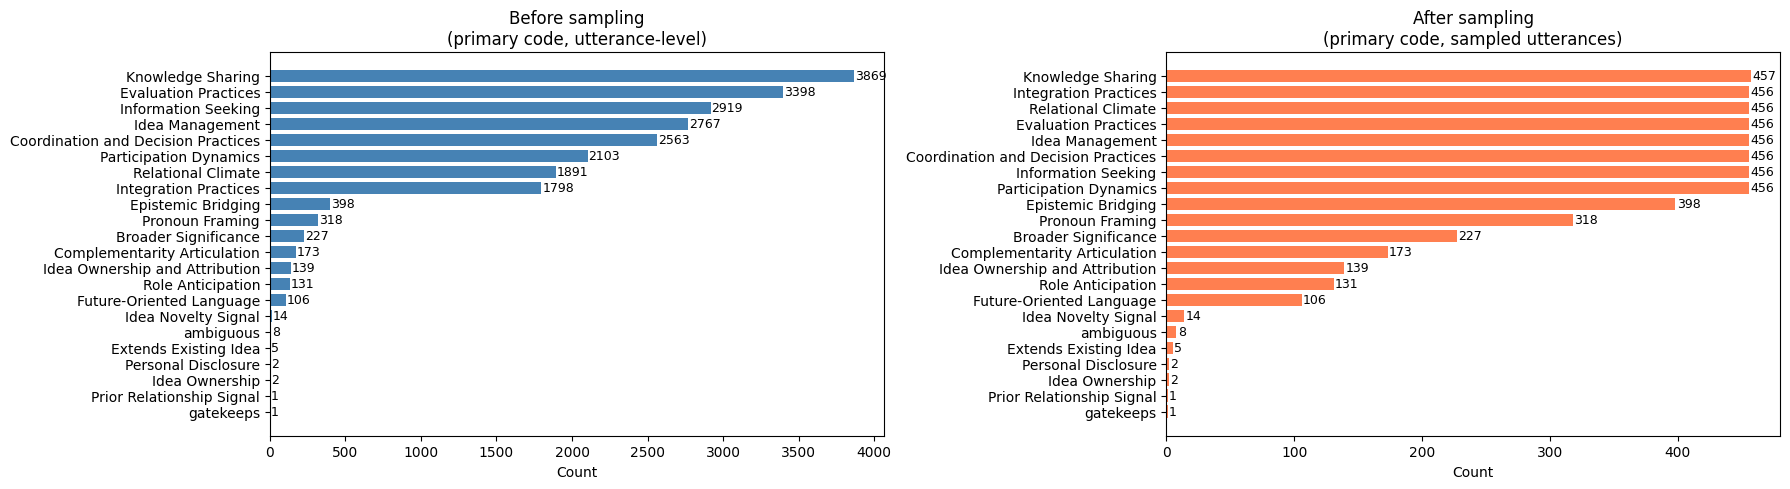

Saved → analysis_v2/notebooks/sampled_v2_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- before ---
orig_vc = df_coded['primary_code'].value_counts()
axes[0].barh(orig_vc.index[::-1], orig_vc.values[::-1], color='steelblue')
axes[0].set_title('Before sampling\n(primary code, utterance-level)', fontsize=12)
axes[0].set_xlabel('Count')
for i, v in enumerate(orig_vc.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# --- after ---
samp_vc = df_sample['primary_code'].value_counts()
axes[1].barh(samp_vc.index[::-1], samp_vc.values[::-1], color='coral')
axes[1].set_title('After sampling\n(primary code, sampled utterances)', fontsize=12)
axes[1].set_xlabel('Count')
for i, v in enumerate(samp_vc.values[::-1]):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(DIST_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {DIST_PNG}")

## 6 · Save output Excel

Columns:
- **conf / session / folder / file / file_path / timestamp** — locators
- **speaker / transcript** — utterance content
- **primary_code / code_names** — Gemini's assigned categories
- Behavioral features (nods, smile, etc.)
- **c1 / c1_ep / c2 / c2_ep / notes** — blank columns for human raters

In [7]:
# Serialize the list of codes to a readable string for Excel
df_sample['code_names_str'] = df_sample['code_names'].apply(
    lambda lst: ' | '.join(lst) if lst else ''
)

# Blank human annotation columns (dash style matching ev_annotation.csv)
for col in ['c1', 'c1-ep', 'c2', 'c2-ep', 'c3', 'c3-ep', 'notes']:
    df_sample[col] = ''

OUTPUT_COLS = [
    # --- locators ---
    'conf', 'session', 'folder', 'file', 'file_path',
    'timestamp', 'speaker',
    # --- human annotation slots (filled in by raters) ---
    'c1', 'c1-ep',
    'c2', 'c2-ep',
    'c3', 'c3-ep',
    'notes',
    # --- behavioural features ---
    'speaking_duration', 'nod_count', 'shared_affect', 'any_smile_other',
    'distracted_count', 'interruption_type', 'overlap', 'vocal_enthusiasm',
    # --- AI annotations pushed to far right for reference ---
    'primary_code', 'code_names_str',
]

df_out = df_sample[OUTPUT_COLS].rename(columns={'code_names_str': 'ai_code_names'})

os.makedirs(os.path.dirname(OUTPUT_EXCEL), exist_ok=True)
df_out.to_excel(OUTPUT_EXCEL, index=False)

print(f"Saved {len(df_out):,} rows → {OUTPUT_EXCEL}")
print(f"Columns: {df_out.columns.tolist()}")
print()
print("Final distribution:")
print(df_out['primary_code'].value_counts().to_string())

Saved 5,174 rows → analysis_v2/notebooks/sampled_v2.xlsx
Columns: ['conf', 'session', 'folder', 'file', 'file_path', 'timestamp', 'speaker', 'c1', 'c1-ep', 'c2', 'c2-ep', 'c3', 'c3-ep', 'notes', 'speaking_duration', 'nod_count', 'shared_affect', 'any_smile_other', 'distracted_count', 'interruption_type', 'overlap', 'vocal_enthusiasm', 'primary_code', 'ai_code_names']

Final distribution:
primary_code
Knowledge Sharing                      457
Integration Practices                  456
Relational Climate                     456
Evaluation Practices                   456
Idea Management                        456
Coordination and Decision Practices    456
Information Seeking                    456
Participation Dynamics                 456
Epistemic Bridging                     398
Pronoun Framing                        318
Broader Significance                   227
Complementarity Articulation           173
Idea Ownership and Attribution         139
Role Anticipation                    

## 7 · Summary stats

In [8]:
print("=" * 60)
print("SAMPLING SUMMARY")
print("=" * 60)
print(f"Total utterances (all confs)  : {len(df_all):,}")
print(f"Utterances with code          : {len(df_coded):,}")
print(f"Sampled (≈20%)                : {len(df_sample):,}  ({len(df_sample)/len(df_all)*100:.1f}%)")
print()
print("By conference:")
print(df_out.groupby('conf').size().rename('n_sampled').to_string())
print()
print("By primary_code:")
print(df_out['primary_code'].value_counts().to_string())
print()
print(f"Output file : {OUTPUT_EXCEL}")
print(f"Use file_path column + your local scialog root to locate videos.")

SAMPLING SUMMARY
Total utterances (all confs)  : 25,874
Utterances with code          : 22,833
Sampled (≈20%)                : 5,174  (20.0%)

By conference:
conf
2020NES    667
2021ABI    619
2021CMC    712
2021MND    557
2021MZT    663
2021NES    674
2021SLU    744
2022MND    538

By primary_code:
primary_code
Knowledge Sharing                      457
Integration Practices                  456
Relational Climate                     456
Evaluation Practices                   456
Idea Management                        456
Coordination and Decision Practices    456
Information Seeking                    456
Participation Dynamics                 456
Epistemic Bridging                     398
Pronoun Framing                        318
Broader Significance                   227
Complementarity Articulation           173
Idea Ownership and Attribution         139
Role Anticipation                      131
Future-Oriented Language               106
Idea Novelty Signal                     1